# Import

In [1]:
!nproc

2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pymysql underthesea scikit-learn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.5 MB/s eta 0:00:00


In [ ]:
!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]


# XGBoost

In [ ]:
!pip install wandb xgboost

In [ ]:
import pandas as pd
import numpy as np
import wandb
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report,
    f1_score, accuracy_score, recall_score, precision_score
)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

WANDB_API_KEY = "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"
wandb.login(key=WANDB_API_KEY)

df_raw = pd.read_csv("/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv")
train_df = df_raw[df_raw['Year'] <= 2021].copy()
test_df  = df_raw[df_raw['Year'] == 2022].copy()

target = 'Next_year_binary_distress_label'
fin_vars = [f'X{i}' for i in range(1, 20)]
features_fin_sen = fin_vars + ['SEN']

count_sound = train_df[target].value_counts()[0]
count_distress = train_df[target].value_counts()[1]
pos_weight_value = count_sound / count_distress

def run_xgboost_with_wandb(features, model_name):
    run = wandb.init(
        project="Distress_Prediction_KLTN",
        name=model_name,
        config={
            "features": "FIN + SEN" if "SEN" in features else "FIN ONLY",
            "model_type": "XGBoost",
            "scale_pos_weight": pos_weight_value
        }
    )

    X_train = train_df[features]
    y_train = train_df[target]
    X_test  = test_df[features]
    y_test  = test_df[target]

    xgb = XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=pos_weight_value
    )

    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 1.0]
    }

    cv = TimeSeriesSplit(n_splits=5)
    grid = GridSearchCV(xgb, param_grid, scoring='f1_macro', cv=cv, n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    probs = best_model.predict_proba(X_test)[:, 1]
    preds = best_model.predict(X_test)

    metrics = {
        "test_auc": roc_auc_score(y_test, probs),
        "test_f1_macro": f1_score(y_test, preds, average='macro'),
        "test_accuracy": accuracy_score(y_test, preds),
        "test_recall_distress": recall_score(y_test, preds),
        "test_precision_distress": precision_score(y_test, preds)
    }

    wandb.config.update(grid.best_params_)
    wandb.log(metrics)

    importance_scores = best_model.feature_importances_
    data = [[f, s] for f, s in zip(features, importance_scores)]
    table = wandb.Table(data=data, columns=["feature", "importance"])
    wandb.log({"feature_importance": wandb.plot.bar(table, "feature", "importance", title="Feature Importance")})

    print(f"\nFinished logging {model_name} to WandB.")
    run.finish()
    return best_model

print("FIN ONLY")
model_fin = run_xgboost_with_wandb(fin_vars, "XGB_FIN_ONLY")

print("FIN + SEN")
model_sen = run_xgboost_with_wandb(features_fin_sen, "XGB_FIN_SEN")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


FIN ONLY


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:50:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Finished logging XGB_FIN_ONLY to WandB.


test_accuracy,▁
test_auc,▁
test_f1_macro,▁
test_precision_distress,▁
test_recall_distress,▁
test_accuracy,0.88602
test_auc,0.9145
test_f1_macro,0.84783
test_precision_distress,0.88546
test_recall_distress,0.68367


FIN + SEN


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:54:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Finished logging XGB_FIN_SEN to WandB.


test_accuracy,▁
test_auc,▁
test_f1_macro,▁
test_precision_distress,▁
test_recall_distress,▁
test_accuracy,0.88123
test_auc,0.92083
test_f1_macro,0.84283
test_precision_distress,0.86325
test_recall_distress,0.68707


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:54:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



==================== XGB FIN ONLY ====================
              precision    recall  f1-score   support

   Sound (0)     0.8862    0.9653    0.9241       750
Distress (1)     0.8855    0.6837    0.7716       294

    accuracy                         0.8860      1044
   macro avg     0.8858    0.8245    0.8478      1044
weighted avg     0.8860    0.8860    0.8811      1044



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:54:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



==================== XGB FIN + SEN ====================
              precision    recall  f1-score   support

   Sound (0)     0.8864    0.9573    0.9205       750
Distress (1)     0.8632    0.6871    0.7652       294

    accuracy                         0.8812      1044
   macro avg     0.8748    0.8222    0.8428      1044
weighted avg     0.8799    0.8812    0.8768      1044



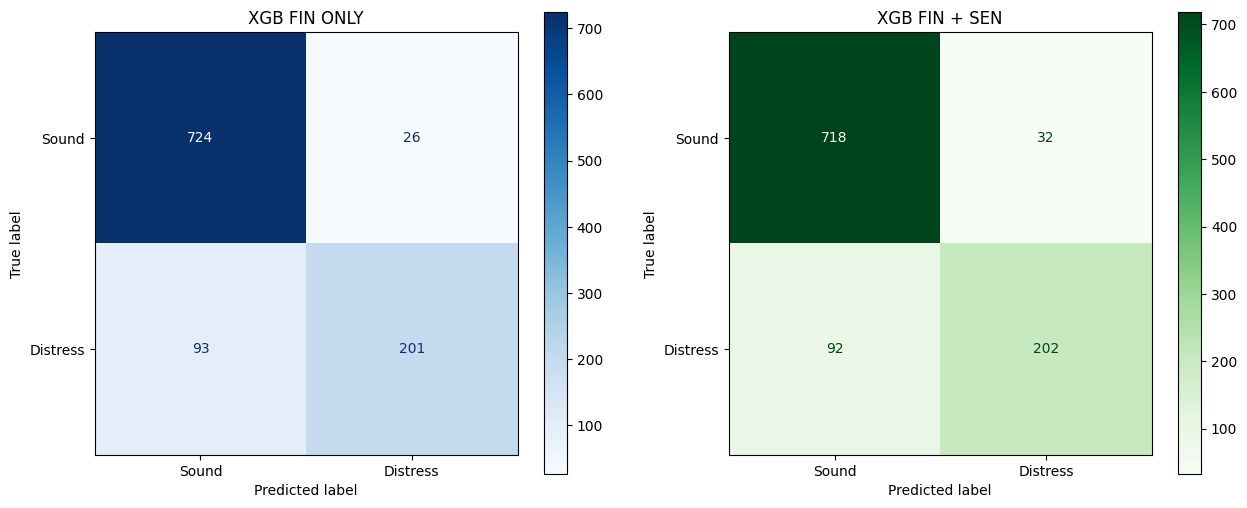

In [ ]:
import wandb
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

api = wandb.Api()

def get_report_from_wandb(run_path, features, title):
    run = api.run(run_path)
    best_params = {k: v for k, v in run.config.items() if k in ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'scale_pos_weight']}

    model = XGBClassifier(**best_params, random_state=42, use_label_encoder=False, eval_metric='logloss')

    model.fit(train_df[features], train_df[target])

    y_pred = model.predict(test_df[features])

    print(f"\n{'='*20} {title} {'='*20}")
    print(classification_report(test_df[target], y_pred, target_names=['Sound (0)', 'Distress (1)'], digits=4))

    return confusion_matrix(test_df[target], y_pred)

cm_fin = get_report_from_wandb("22028316-uet-vnu/Distress_Prediction_KLTN/ipea92s6", fin_vars, "XGB FIN ONLY")
cm_sen = get_report_from_wandb("22028316-uet-vnu/Distress_Prediction_KLTN/q71udndt", features_fin_sen, "XGB FIN + SEN")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ConfusionMatrixDisplay(cm_fin, display_labels=['Sound', 'Distress']).plot(ax=ax1, cmap='Blues')
ax1.set_title('XGB FIN ONLY')
ConfusionMatrixDisplay(cm_sen, display_labels=['Sound', 'Distress']).plot(ax=ax2, cmap='Greens')
ax2.set_title('XGB FIN + SEN')
plt.show()

--- Đang truy xuất dữ liệu từ: XGB_FIN_SEN ---


wandb:   1 of 1 files downloaded.  
/tmp/ipykernel_17284/331677281.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=df_importance, palette=colors)


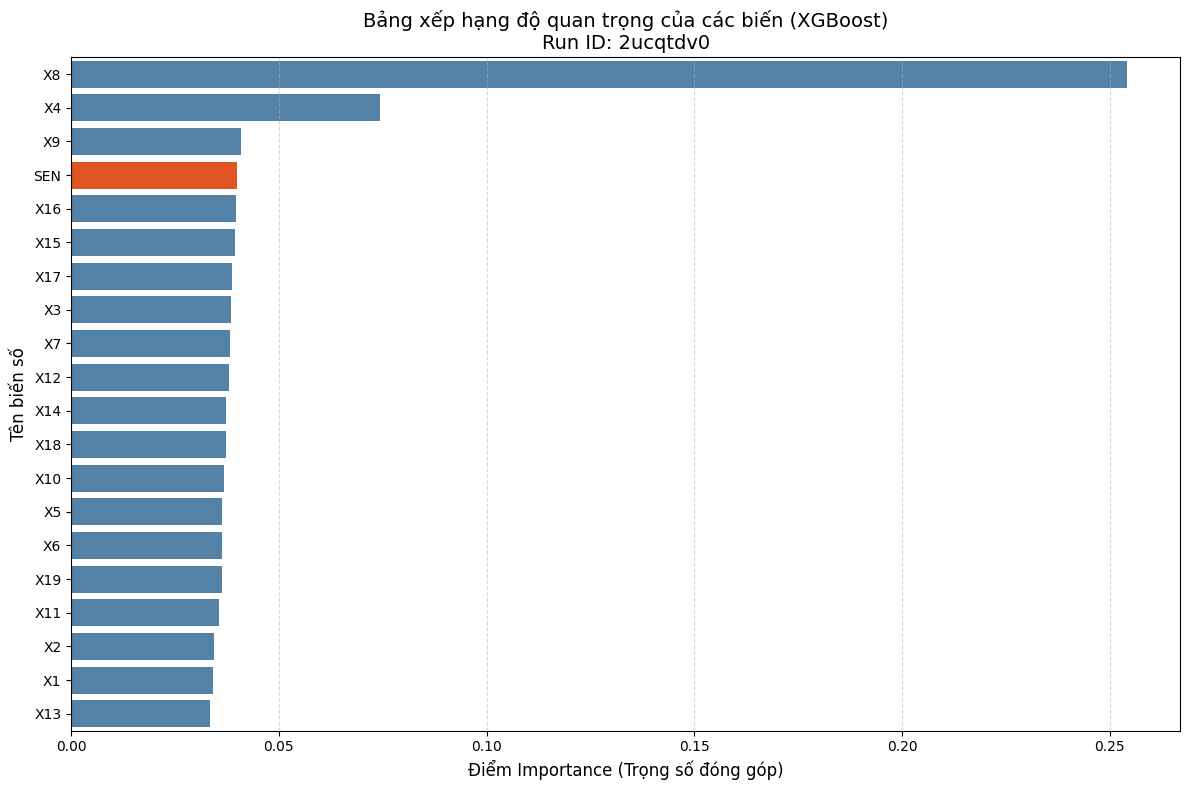


--- TOP 10 BIẾN QUAN TRỌNG NHẤT ---
   feature  importance
7       X8    0.254220
3       X4    0.074444
8       X9    0.040968
19     SEN    0.039909
15     X16    0.039715
14     X15    0.039378
16     X17    0.038638
2       X3    0.038547
6       X7    0.038271
11     X12    0.037992


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wandb

api = wandb.Api()
run_path = "22028316-uet-vnu/Distress_Prediction_KLTN/q71udndt"

def get_importance_from_history(run_path):
    run = api.run(run_path)
    print(f"--- Đang truy xuất dữ liệu từ: {run.name} ---")

    try:
        artifacts = run.logged_artifacts()
        table_artifact = [a for a in artifacts if 'run_table' in a.name or 'feature_importance' in a.name][0]

        datadir = table_artifact.download()

        import os
        import json
        json_file = [f for f in os.listdir(datadir) if f.endswith('.json')][0]

        with open(os.path.join(datadir, json_file)) as f:
            data = json.load(f)

        df_importance = pd.DataFrame(data['data'], columns=data['columns'])
        df_importance = df_importance.sort_values(by='importance', ascending=False)

        plt.figure(figsize=(12, 8))
        colors = ['#FF4500' if x == 'SEN' else '#4682B4' for x in df_importance['feature']]
        sns.barplot(x='importance', y='feature', data=df_importance, palette=colors)

        plt.title(f'Bảng xếp hạng độ quan trọng của các biến (XGBoost)\nRun ID: 2ucqtdv0', fontsize=14)
        plt.xlabel('Điểm Importance (Trọng số đóng góp)', fontsize=12)
        plt.ylabel('Tên biến số', fontsize=12)
        plt.grid(axis='x', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        return df_importance

    except Exception as e:
        print(f"Lỗi khi truy xuất: {e}")
        print("Mẹo: Nếu code không chạy, bạn hãy chụp màn hình biểu đồ 'feature_importance_table' trực tiếp trên Web WandB nhé!")
        return None

df_imp = get_importance_from_history(run_path)

if df_imp is not None:
    print("\n--- TOP 10 BIẾN QUAN TRỌNG NHẤT ---")
    print(df_imp.head(10))

# LR

In [ ]:
import pandas as pd
import numpy as np
import wandb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, recall_score, precision_score
)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

def run_lr_with_wandb(features, model_name):
    run = wandb.init(
        project="Distress_Prediction_KLTN",
        name=model_name,
        config={
            "features": "FIN + SEN" if "SEN" in features else "FIN ONLY",
            "model_type": "LogisticRegression",
            "sampling": "SMOTE"
        },
        reinit=True
    )

    X_train = train_df[features]
    y_train = train_df[target]
    X_test  = test_df[features]
    y_test  = test_df[target]

    pipe = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('lr', LogisticRegression(random_state=42, max_iter=2000))
    ])

    param_grid = {
        'lr__C': [0.01, 0.1, 1, 10, 100],
        'lr__penalty': ['l2']
    }

    cv = TimeSeriesSplit(n_splits=5)
    grid = GridSearchCV(pipe, param_grid, scoring='f1_macro', cv=cv, n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    probs = best_model.predict_proba(X_test)[:, 1]
    preds = best_model.predict(X_test)

    metrics = {
        "test_auc": roc_auc_score(y_test, probs),
        "test_f1_macro": f1_score(y_test, preds, average='macro'),
        "test_accuracy": accuracy_score(y_test, preds),
        "test_recall_distress": recall_score(y_test, preds),
        "test_precision_distress": precision_score(y_test, preds)
    }

    wandb.config.update(grid.best_params_)
    wandb.log(metrics)

    coefs = best_model.named_steps['lr'].coef_[0]
    data = [[f, c] for f, c in zip(features, coefs)]
    table = wandb.Table(data=data, columns=["feature", "coefficient"])
    wandb.log({"feature_coefficients": wandb.plot.bar(table, "feature", "coefficient", title="LR Coefficients")})

    print(f"\nFinished logging {model_name} to WandB.")
    run.finish()
    return best_model

print("LR FIN ONLY")
model_lr_fin = run_lr_with_wandb(fin_vars, "LR_FIN_ONLY")

print("LR FIN + SEN")
model_lr_sen = run_lr_with_wandb(features_fin_sen, "LR_FIN_SEN")

LR FIN ONLY



Finished logging LR_FIN_ONLY to WandB.


test_accuracy,▁
test_auc,▁
test_f1_macro,▁
test_precision_distress,▁
test_recall_distress,▁
test_accuracy,0.841
test_auc,0.88654
test_f1_macro,0.80778
test_precision_distress,0.70253
test_recall_distress,0.7551


LR FIN + SEN



Finished logging LR_FIN_SEN to WandB.


test_accuracy,▁
test_auc,▁
test_f1_macro,▁
test_precision_distress,▁
test_recall_distress,▁
test_accuracy,0.84195
test_auc,0.88801
test_f1_macro,0.80875
test_precision_distress,0.70476
test_recall_distress,0.7551



==================== LR FIN ONLY ====================
              precision    recall  f1-score   support

   Sound (0)     0.9011    0.8747    0.8877       750
Distress (1)     0.7025    0.7551    0.7279       294

    accuracy                         0.8410      1044
   macro avg     0.8018    0.8149    0.8078      1044
weighted avg     0.8452    0.8410    0.8427      1044


==================== LR FIN + SEN ====================
              precision    recall  f1-score   support

   Sound (0)     0.9012    0.8760    0.8884       750
Distress (1)     0.7048    0.7551    0.7291       294

    accuracy                         0.8420      1044
   macro avg     0.8030    0.8156    0.8088      1044
weighted avg     0.8459    0.8420    0.8436      1044



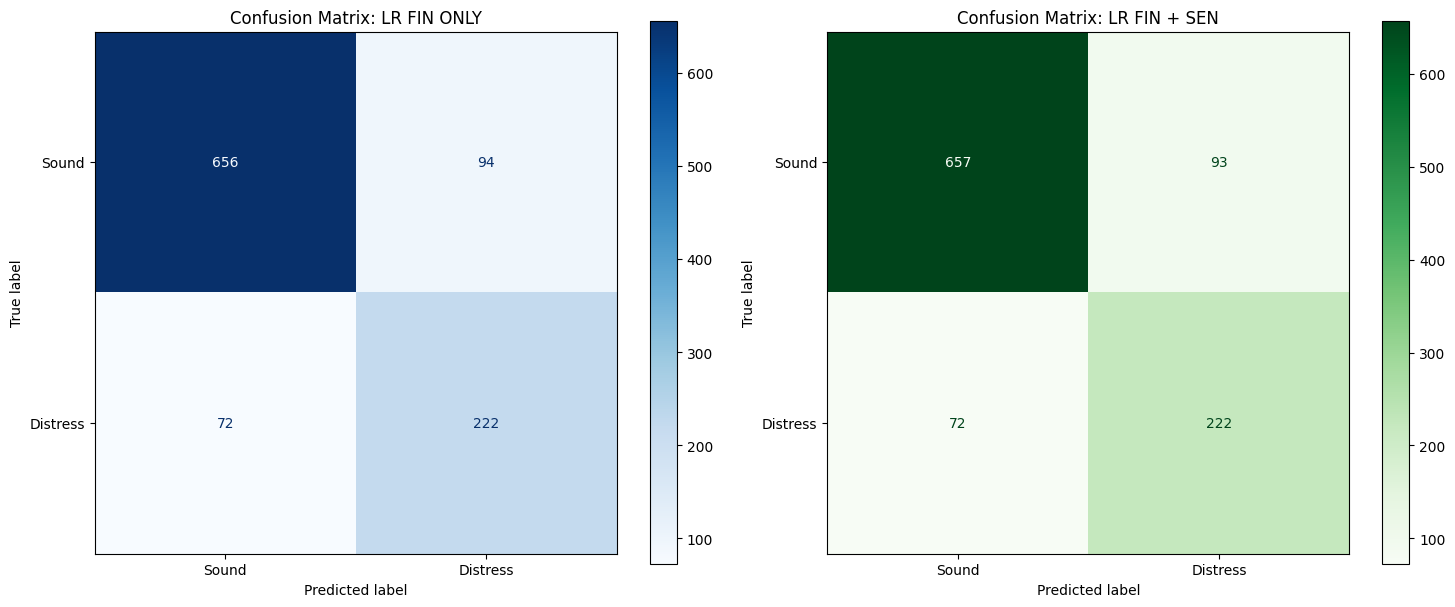

In [ ]:
import wandb
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

api = wandb.Api()

def get_lr_report(run_id, features, title):
    run_path = f"22028316-uet-vnu/Distress_Prediction_KLTN/{run_id}"
    run = api.run(run_path)

    best_params = {k.replace('lr__', ''): v for k, v in run.config.items() if 'lr__' in k or k in ['C', 'penalty']}

    model = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('lr', LogisticRegression(**best_params, random_state=42, max_iter=2000))
    ])

    model.fit(train_df[features], train_df[target])

    y_pred = model.predict(test_df[features])

    print(f"\n{'='*20} {title} {'='*20}")
    print(classification_report(test_df[target], y_pred, target_names=['Sound (0)', 'Distress (1)'], digits=4))

    return confusion_matrix(test_df[target], y_pred)

cm_lr_fin = get_lr_report("sd95ykdm", fin_vars, "LR FIN ONLY")
cm_lr_sen = get_lr_report("a7z8yj8u", features_fin_sen, "LR FIN + SEN")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay(cm_lr_fin, display_labels=['Sound', 'Distress']).plot(ax=ax1, cmap='Blues')
ax1.set_title('Confusion Matrix: LR FIN ONLY')

ConfusionMatrixDisplay(cm_lr_sen, display_labels=['Sound', 'Distress']).plot(ax=ax2, cmap='Greens')
ax2.set_title('Confusion Matrix: LR FIN + SEN')

plt.tight_layout()
plt.show()

--- Đang trích xuất Hệ số hồi quy từ Run: LR_FIN_SEN ---


wandb:   1 of 1 files downloaded.  
/tmp/ipykernel_17284/6798060.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coef_col, y=feat_col, data=df_lr, palette=colors)


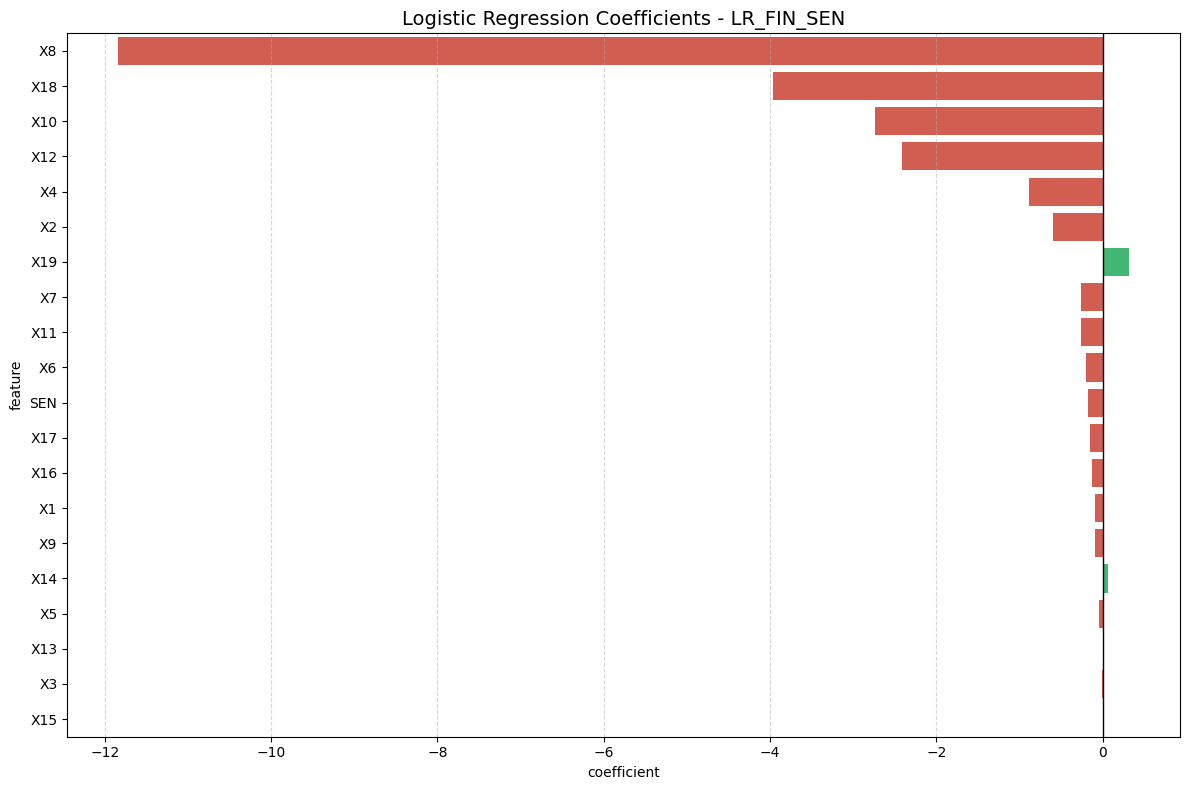


--- BẢNG HỆ SỐ CHI TIẾT ---
   feature  coefficient
7       X8   -11.843839
17     X18    -3.970759
9      X10    -2.742142
11     X12    -2.409020
3       X4    -0.889743
1       X2    -0.601383
18     X19     0.319837
6       X7    -0.267470
10     X11    -0.262898
5       X6    -0.197623
19     SEN    -0.178367
16     X17    -0.152970
15     X16    -0.128613
0       X1    -0.089649
8       X9    -0.088945
13     X14     0.065406
4       X5    -0.040363
12     X13     0.010964
2       X3    -0.010266
14     X15     0.006054


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import os
import json

api = wandb.Api()
run_path = "22028316-uet-vnu/Distress_Prediction_KLTN/a7z8yj8u"
run = api.run(run_path)

print(f"--- Đang trích xuất Hệ số hồi quy từ Run: {run.name} ---")

try:
    artifacts = run.logged_artifacts()
    table_art = [a for a in artifacts if 'table' in a.name][0]

    dir_path = table_art.download()
    json_path = [f for f in os.listdir(dir_path) if f.endswith('.json')][0]

    with open(os.path.join(dir_path, json_path), 'r') as f:
        table_data = json.load(f)

    df_lr = pd.DataFrame(table_data['data'], columns=table_data['columns'])

    df_lr['abs_val'] = df_lr.iloc[:, 1].abs()
    df_lr = df_lr.sort_values(by='abs_val', ascending=False)

    plt.figure(figsize=(12, 8))
    feat_col = df_lr.columns[0]
    coef_col = df_lr.columns[1]

    colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in df_lr[coef_col]]
    sns.barplot(x=coef_col, y=feat_col, data=df_lr, palette=colors)

    plt.axvline(0, color='black', lw=1)
    plt.title(f'Logistic Regression Coefficients - {run.name}', fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print("\n--- BẢNG HỆ SỐ CHI TIẾT ---")
    print(df_lr[[feat_col, coef_col]].head(20))

except Exception as e:
    print(f"Lỗi truy xuất bảng: {e}")
    print("Mẹo: Bạn có thể vào link này, chọn tab 'Media' để xem biểu đồ: " + run.url)

# RF

In [6]:
import pandas as pd
import numpy as np
import wandb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, recall_score, precision_score
)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

WANDB_API_KEY = "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"
wandb.login(key=WANDB_API_KEY)

df_raw = pd.read_csv("/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv")

train_df = df_raw[df_raw['Year'] <= 2021].copy()
test_df  = df_raw[df_raw['Year'] == 2022].copy()

target = 'Next_year_binary_distress_label'
fin_vars = [f'X{i}' for i in range(1, 20)]
#features_fin_sen = fin_vars + ['SEN']

def run_rf_pipeline_wandb(features, model_name):
    run = wandb.init(
        project="Distress_Prediction_KLTN",
        name=model_name,
        config={
            "features": "FIN + SEN" if "SEN" in features else "FIN ONLY",
            "model_type": "RandomForest_Pipeline",
            "sampling": "SMOTE_inside_CV"
        },
        reinit=True
    )

    X_train = train_df[features]
    y_train = train_df[target]
    X_test  = test_df[features]
    y_test  = test_df[target]

    pipe = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42))
    ])

    param_grid = {
        'rf__n_estimators': [100, 200, 300],
        'rf__max_depth': [5, 8, 12, None],
        'rf__min_samples_split': [2, 5],
        'rf__min_samples_leaf': [1, 2],
        'rf__max_features': ['sqrt', 'log2'],
        'rf__bootstrap': [True, False]
    }

    cv = TimeSeriesSplit(n_splits=5)

    grid = GridSearchCV(
        pipe,
        param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    probs = best_model.predict_proba(X_test)[:, 1]
    preds = best_model.predict(X_test)

    metrics = {
        "test_auc": roc_auc_score(y_test, probs),
        "test_f1_macro": f1_score(y_test, preds, average='macro'),
        "test_accuracy": accuracy_score(y_test, preds),
        "test_recall_distress": recall_score(y_test, (probs >= 0.5).astype(int)),
        "test_precision_distress": precision_score(y_test, (probs >= 0.5).astype(int))
    }

    wandb.config.update(grid.best_params_)
    wandb.log(metrics)

    rf_inner = best_model.named_steps['rf']
    importance_scores = rf_inner.feature_importances_
    data = [[f, s] for f, s in zip(features, importance_scores)]
    table = wandb.Table(data=data, columns=["feature", "importance"])
    wandb.log({"feature_importance": wandb.plot.bar(table, "feature", "importance", title="RF Feature Importance")})

    print(f"\nFinished logging {model_name} to WandB.")
    run.finish()
    return best_model

print("--- RUNNING RF: FIN ONLY ---")
model_rf_fin = run_rf_pipeline_wandb(fin_vars, "RF_PIPELINE_FIN_ONLY")

# print("--- RUNNING RF: FIN + SEN ---")
# model_rf_sen = run_rf_pipeline_wandb(features_fin_sen, "RF_PIPELINE_FIN_SEN")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 22028316 (22028316-uet-vnu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


--- RUNNING RF: FIN ONLY ---


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Fitting 5 folds for each of 192 candidates, totalling 960 fits

Finished logging RF_PIPELINE_FIN_ONLY to WandB.


test_accuracy,▁
test_auc,▁
test_f1_macro,▁
test_precision_distress,▁
test_recall_distress,▁
test_accuracy,0.88314
test_auc,0.92506
test_f1_macro,0.84651
test_precision_distress,0.85833
test_recall_distress,0.70068


In [7]:
import pandas as pd
import numpy as np
import wandb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, recall_score, precision_score
)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

WANDB_API_KEY = "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"
wandb.login(key=WANDB_API_KEY)

df_raw = pd.read_csv("/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv")

train_df = df_raw[df_raw['Year'] <= 2021].copy()
test_df  = df_raw[df_raw['Year'] == 2022].copy()

target = 'Next_year_binary_distress_label'
#fin_vars = [f'X{i}' for i in range(1, 20)]
features_fin_sen = [f'X{i}' for i in range(1, 20)] + ['SEN']

def run_rf_pipeline_wandb(features, model_name):
    run = wandb.init(
        project="Distress_Prediction_KLTN",
        name=model_name,
        config={
            "features": "FIN + SEN" if "SEN" in features else "FIN ONLY",
            "model_type": "RandomForest_Pipeline",
            "sampling": "SMOTE_inside_CV"
        },
        reinit=True
    )

    X_train = train_df[features]
    y_train = train_df[target]
    X_test  = test_df[features]
    y_test  = test_df[target]

    pipe = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('rf', RandomForestClassifier(
            random_state=42,
            class_weight="balanced"))
    ])

    param_grid = {
        'rf__n_estimators': [100, 200, 300],
        'rf__max_depth': [5, 8, 12, None],
        'rf__min_samples_split': [2, 5],
        'rf__min_samples_leaf': [1, 2],
        'rf__max_features': ['sqrt', 'log2'],
        'rf__bootstrap': [True, False]
    }

    cv = TimeSeriesSplit(n_splits=5)

    grid = GridSearchCV(
        pipe,
        param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    probs = best_model.predict_proba(X_test)[:, 1]
    preds = best_model.predict(X_test)

    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f1 = 0
    best_th = 0.5

    for th in thresholds:
        preds_tmp = (probs >= th).astype(int)
        f1 = f1_score(y_test, preds_tmp, average='macro')

        if f1 > best_f1:
            best_f1 = f1
            best_th = th

    preds = (probs >= best_th).astype(int)

    metrics = {
        "best_threshold": best_th,
        "test_auc": roc_auc_score(y_test, probs),
        "test_f1_macro": f1_score(y_test, preds, average='macro'),
        "test_accuracy": accuracy_score(y_test, preds),
        "test_recall_distress": recall_score(y_test, preds),
        "test_precision_distress": precision_score(y_test, preds)
    }

    wandb.config.update(grid.best_params_)
    wandb.log(metrics)

    rf_inner = best_model.named_steps['rf']
    importance_scores = rf_inner.feature_importances_
    data = [[f, s] for f, s in zip(features, importance_scores)]
    table = wandb.Table(data=data, columns=["feature", "importance"])
    wandb.log({"feature_importance": wandb.plot.bar(table, "feature", "importance", title="RF Feature Importance")})

    print(f"\nFinished logging {model_name} to WandB.")
    run.finish()
    return best_model

# print("--- RUNNING RF: FIN ONLY ---")
# model_rf_fin = run_rf_pipeline_wandb(fin_vars, "RF_PIPELINE_FIN_ONLY")

print("--- RUNNING RF: FIN + SEN ---")
model_rf_sen = run_rf_pipeline_wandb(features_fin_sen, "RF_PIPELINE_FIN_SEN")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


--- RUNNING RF: FIN + SEN ---


Fitting 5 folds for each of 192 candidates, totalling 960 fits

Finished logging RF_PIPELINE_FIN_SEN to WandB.


best_threshold,▁
test_accuracy,▁
test_auc,▁
test_f1_macro,▁
test_precision_distress,▁
test_recall_distress,▁
best_threshold,0.55
test_accuracy,0.88889
test_auc,0.92622
test_f1_macro,0.85334
test_precision_distress,0.87712


In [ ]:
import joblib
joblib.dump(
    model_rf_sen,
    "/content/drive/MyDrive/KLTN/rf_best_model.pkl"
)

In [3]:
import joblib

model_rf_sen = joblib.load(
    "/content/drive/MyDrive/KLTN/rf_best_model.pkl"
)

==================== CLASSIFICATION REPORT: FIN + SEN ====================
              precision    recall  f1-score   support

   Sound (0)     0.8923    0.9613    0.9255       750
Distress (1)     0.8771    0.7041    0.7811       294

    accuracy                         0.8889      1044
   macro avg     0.8847    0.8327    0.8533      1044
weighted avg     0.8880    0.8889    0.8849      1044


Confusion Matrix:
[[721  29]
 [ 87 207]]


<Figure size 800x600 with 0 Axes>

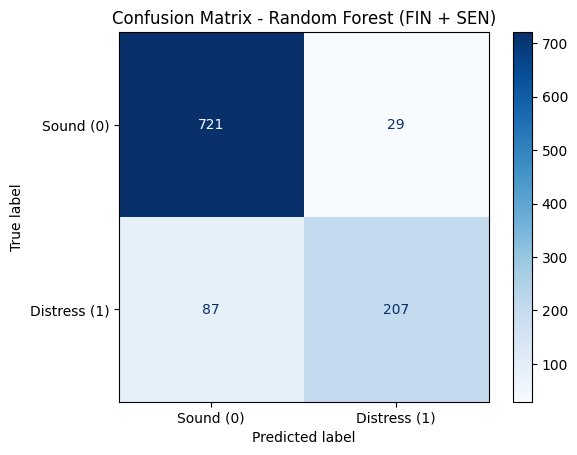


Phân tích nhanh:
- Số ca Distress (1) đoán đúng (True Positive): 207/294
- Số ca Sound (0) bị đoán nhầm thành Distress (False Positive): 29


In [8]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_rf_model = model_rf_sen

X_test_sen = test_df[features_fin_sen]
y_test = test_df[target]

best_th = 0.55  # lấy từ wandb log

y_prob = best_rf_model.predict_proba(X_test_sen)[:, 1]
y_pred = (y_prob >= best_th).astype(int)

print("="*20, "CLASSIFICATION REPORT: FIN + SEN", "="*20)
print(classification_report(y_test, y_pred, target_names=['Sound (0)', 'Distress (1)'], digits=4))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sound (0)', 'Distress (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest (FIN + SEN)')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nPhân tích nhanh:")
print(f"- Số ca Distress (1) đoán đúng (True Positive): {tp}/{tp+fn}")
print(f"- Số ca Sound (0) bị đoán nhầm thành Distress (False Positive): {fp}")


==================== REPORT: FIN ONLY ====================
Threshold = 0.5
              precision    recall  f1-score   support

   Sound (0)     0.8905    0.9547    0.9215       750
Distress (1)     0.8583    0.7007    0.7715       294

    accuracy                         0.8831      1044
   macro avg     0.8744    0.8277    0.8465      1044
weighted avg     0.8815    0.8831    0.8793      1044


==================== REPORT: FIN + SEN ====================
Threshold = 0.55
              precision    recall  f1-score   support

   Sound (0)     0.8923    0.9613    0.9255       750
Distress (1)     0.8771    0.7041    0.7811       294

    accuracy                         0.8889      1044
   macro avg     0.8847    0.8327    0.8533      1044
weighted avg     0.8880    0.8889    0.8849      1044



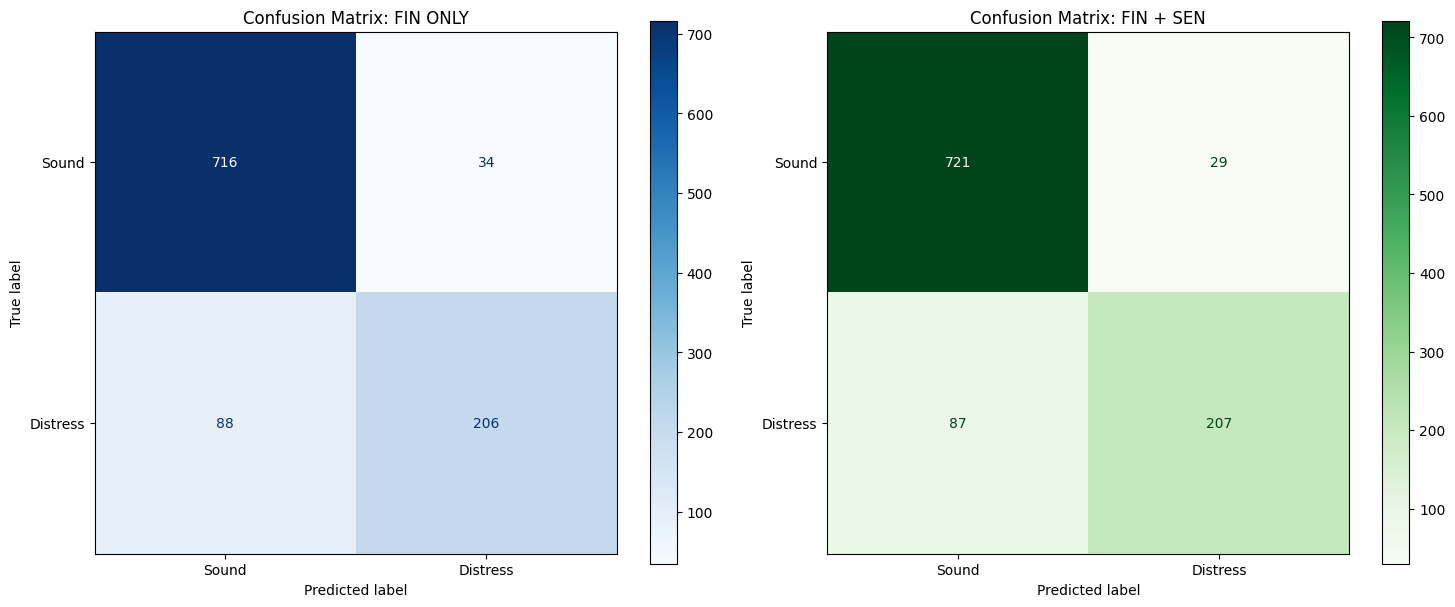


--- PHÂN TÍCH SO SÁNH ---
Số ca Distress đoán đúng (FIN ONLY): 206
Số ca Distress đoán đúng (FIN + SEN): 207
 => Biến SEN giúp nhận diện thêm ĐÚNG 1 doanh nghiệp đang gặp nguy hiểm.


In [10]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_and_plot(model, features, title, threshold=0.55):
    X_test = test_df[features]
    y_test = test_df[target]

    # ❗ Lấy xác suất lớp 1 (Distress)
    y_prob = model.predict_proba(X_test)[:, 1]

    # ❗ Apply threshold
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\n{'='*20} {title} {'='*20}")
    print(f"Threshold = {threshold}")
    print(classification_report(y_test, y_pred, target_names=['Sound (0)', 'Distress (1)'], digits=4))

    cm = confusion_matrix(y_test, y_pred)
    return cm

cm_fin = evaluate_and_plot(model_rf_fin, fin_vars, "REPORT: FIN ONLY", threshold=0.5)
cm_sen = evaluate_and_plot(model_rf_sen, features_fin_sen, "REPORT: FIN + SEN", threshold=0.55)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_fin, display_labels=['Sound', 'Distress'])
disp1.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title('Confusion Matrix: FIN ONLY')

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_sen, display_labels=['Sound', 'Distress'])
disp2.plot(ax=ax2, cmap='Greens', values_format='d')
ax2.set_title('Confusion Matrix: FIN + SEN')

plt.tight_layout()
plt.show()

tp_fin = cm_fin[1, 1]
tp_sen = cm_sen[1, 1]
improvement = tp_sen - tp_fin

print(f"\n--- PHÂN TÍCH SO SÁNH ---")
print(f"Số ca Distress đoán đúng (FIN ONLY): {tp_fin}")
print(f"Số ca Distress đoán đúng (FIN + SEN): {tp_sen}")
print(f" => Biến SEN giúp nhận diện thêm ĐÚNG {improvement} doanh nghiệp đang gặp nguy hiểm.")

--- Đang trích xuất Feature Importance từ: RF_PIPELINE_FIN_SEN ---


wandb:   1 of 1 files downloaded.  
/tmp/ipykernel_3172/746091365.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=df, palette=colors)


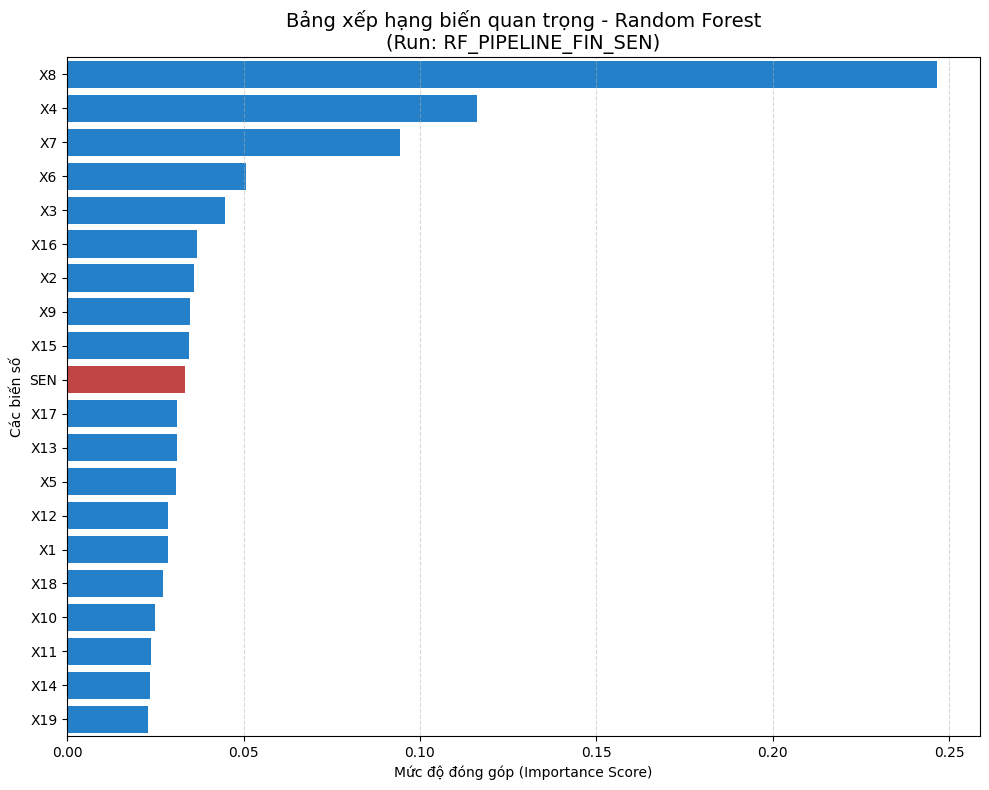


Top 10 biến quan trọng nhất của Random Forest:
   feature  importance
7       X8    0.246419
3       X4    0.116249
6       X7    0.094407
5       X6    0.050826
2       X3    0.044621
15     X16    0.036932
1       X2    0.036026
8       X9    0.034783
14     X15    0.034516
19     SEN    0.033309


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import os
import json

api = wandb.Api()
run_path = "22028316-uet-vnu/Distress_Prediction_KLTN/runs/nhxxygx7"

def get_rf_importance_from_wandb(path):
    run = api.run(path)
    print(f"--- Đang trích xuất Feature Importance từ: {run.name} ---")

    try:
        artifacts = run.logged_artifacts()
        table_art = [a for a in artifacts if 'feature_importance' in a.name][0]

        dir_path = table_art.download()
        json_path = [f for f in os.listdir(dir_path) if f.endswith('.json')][0]

        with open(os.path.join(dir_path, json_path), 'r') as f:
            table_data = json.load(f)

        df = pd.DataFrame(table_data['data'], columns=table_data['columns'])
        df = df.sort_values(by='importance', ascending=False)

        plt.figure(figsize=(10, 8))
        colors = ['#d63031' if x == 'SEN' else '#0984e3' for x in df['feature']]

        sns.barplot(x='importance', y='feature', data=df, palette=colors)
        plt.title(f'Bảng xếp hạng biến quan trọng - Random Forest\n(Run: {run.name})', fontsize=14)
        plt.xlabel('Mức độ đóng góp (Importance Score)')
        plt.ylabel('Các biến số')
        plt.grid(axis='x', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        return df

    except Exception as e:
        print(f"Lỗi: {e}")
        print("Check: " + run.url)
        return None

# Thực thi
df_rf_imp = get_rf_importance_from_wandb(run_path)

if df_rf_imp is not None:
    print("\nTop 10 biến quan trọng nhất của Random Forest:")
    print(df_rf_imp.head(10))

## SHAP

In [ ]:
import pandas as pd
import numpy as np
import wandb
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

WANDB_API_KEY = "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"
wandb.login(key=WANDB_API_KEY)
api = wandb.Api()

df_raw = pd.read_csv("/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv")
train_df = df_raw[df_raw['Year'] <= 2021].copy()
test_df  = df_raw[df_raw['Year'] == 2022].copy()

target = 'Next_year_binary_distress_label'
fin_vars = [f'X{i}' for i in range(1, 20)]
features_fin_sen = fin_vars + ['SEN']

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


In [ ]:
run = api.run("22028316-uet-vnu/Distress_Prediction_KLTN/runs/nhxxygx7")
best_params = {k.replace('rf__', ''): v for k, v in run.config.items() if 'rf__' in k or k in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features', 'bootstrap']}

final_pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(**best_params, random_state=42))
])

final_pipe.fit(train_df[features_fin_sen], train_df[target])

Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('rf',
                 RandomForestClassifier(bootstrap=False, n_estimators=300,
                                        random_state=42))])

In [ ]:
X_test_sen = test_df[features_fin_sen]
X_test_scaled = final_pipe.named_steps['scaler'].transform(X_test_sen)

rf_model = final_pipe.named_steps['rf']

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled[:200])

shap_values_distress = shap_values[1]

Kích thước X_sample: (200, 20)
Kích thước SHAP values: (200, 20)
Số lượng tên biến: 20


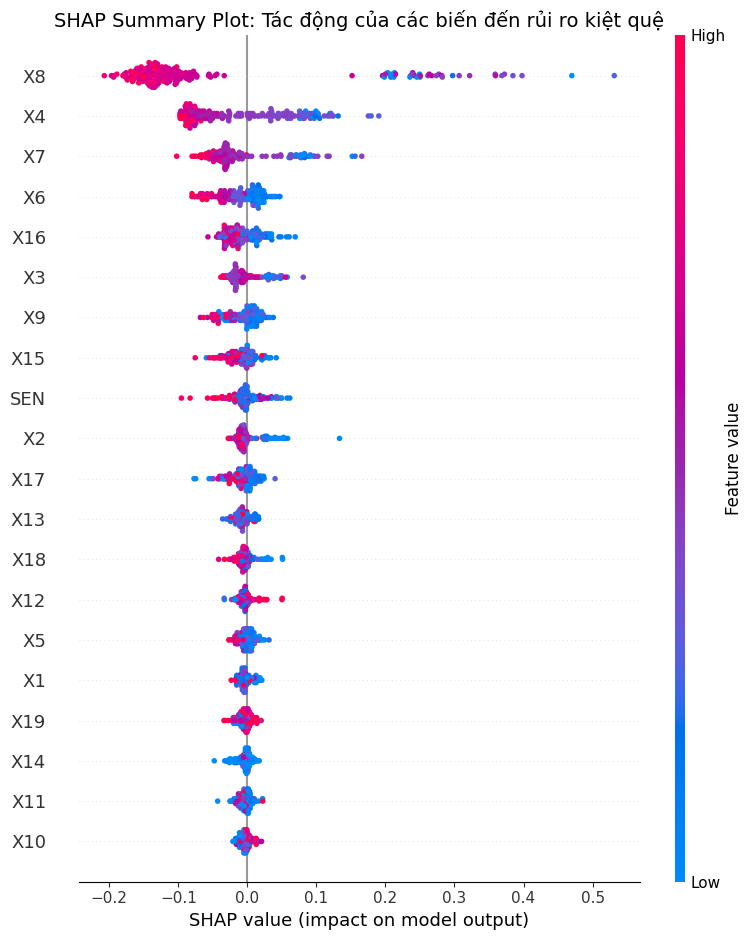

In [ ]:
import matplotlib.pyplot as plt
import shap

num_samples = 200
X_sample = X_test_scaled[:num_samples]

if isinstance(shap_values, list):

    shap_values_to_plot = shap_values[1][:num_samples]
else:
    if len(shap_values.shape) == 3:
        shap_values_to_plot = shap_values[:num_samples, :, 1]
    else:
        shap_values_to_plot = shap_values[:num_samples]

print(f"Kích thước X_sample: {X_sample.shape}")
print(f"Kích thước SHAP values: {shap_values_to_plot.shape}")
print(f"Số lượng tên biến: {len(features_fin_sen)}")

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_to_plot,
    X_sample,
    feature_names=features_fin_sen,
    show=False
)
plt.title("SHAP Summary Plot: Tác động của các biến đến rủi ro kiệt quệ", fontsize=14)
plt.tight_layout()
plt.show()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/dautruclinh/.netrc


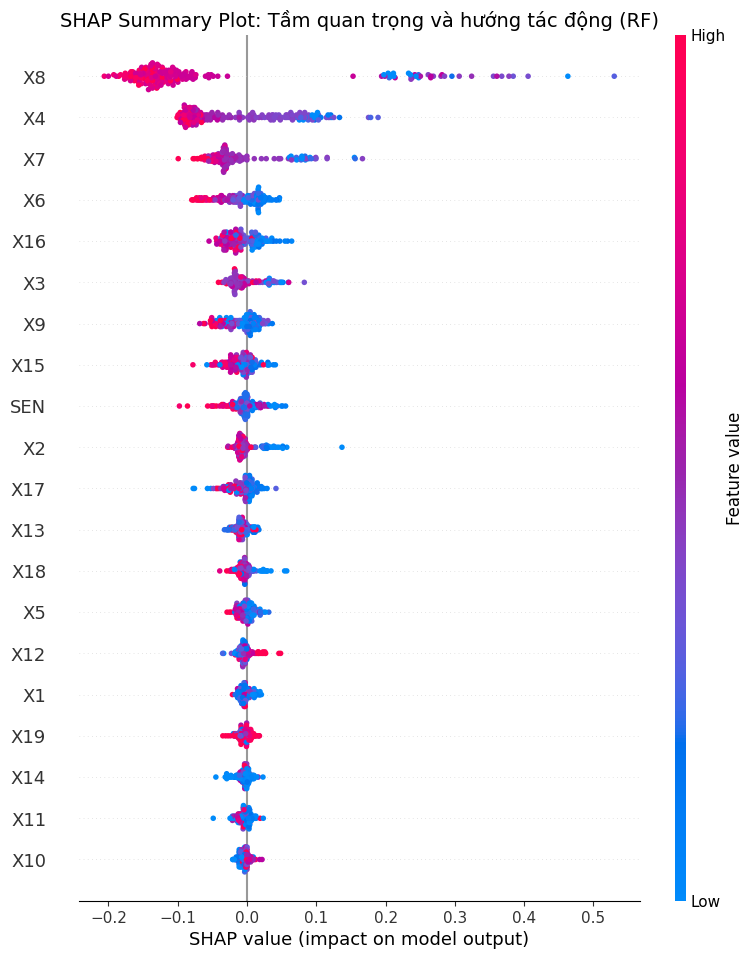


--- Đã tìm thấy mẫu có biến SEN tác động mạnh nhất: Index 105 ---


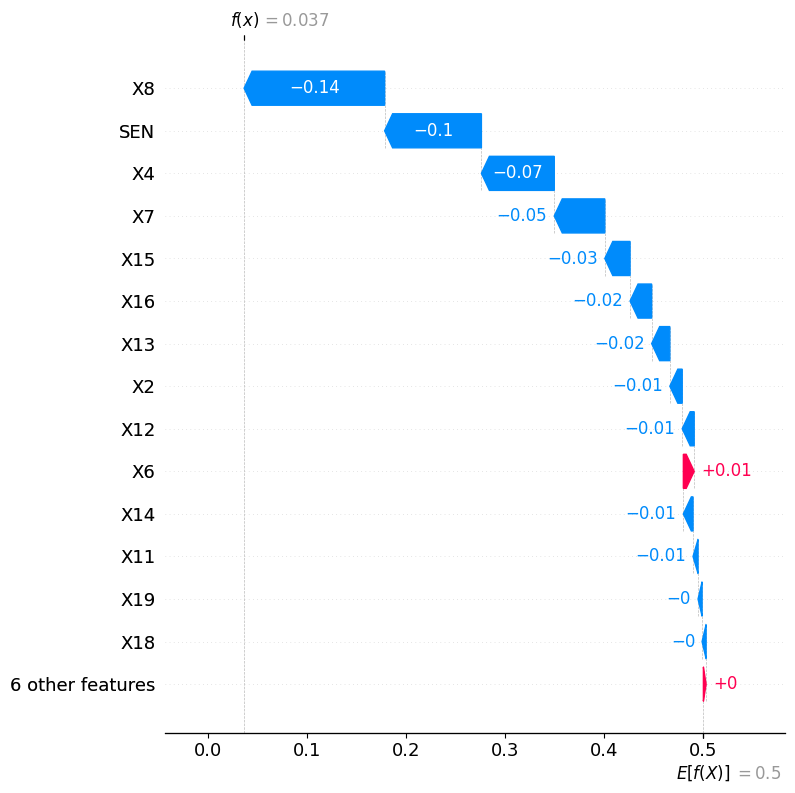

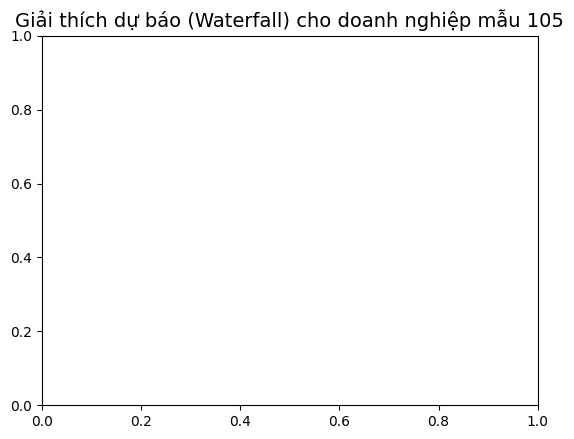

In [ ]:
import pandas as pd
import numpy as np
import wandb
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

WANDB_API_KEY = "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"
wandb.login(key=WANDB_API_KEY)
api = wandb.Api()

df_raw = pd.read_csv("/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv")
train_df = df_raw[df_raw['Year'] <= 2021].copy()
test_df  = df_raw[df_raw['Year'] == 2022].copy()

target = 'Next_year_binary_distress_label'
fin_vars = [f'X{i}' for i in range(1, 20)]
features_fin_sen = fin_vars + ['SEN']

run = api.run("22028316-uet-vnu/Distress_Prediction_KLTN/runs/nhxxygx7")
best_params = {k.replace('rf__', ''): v for k, v in run.config.items() if 'rf__' in k or k in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features', 'bootstrap']}

final_pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(**best_params, random_state=42))
])
final_pipe.fit(train_df[features_fin_sen], train_df[target])

X_test_scaled = final_pipe.named_steps['scaler'].transform(test_df[features_fin_sen])
rf_model = final_pipe.named_steps['rf']
explainer = shap.TreeExplainer(rf_model)

num_samples = 200
shap_values = explainer.shap_values(X_test_scaled[:num_samples])

if isinstance(shap_values, list):
    shap_values_distress = shap_values[1]
    expected_value = explainer.expected_value[1]
else:
    shap_values_distress = shap_values[:, :, 1]
    expected_value = explainer.expected_value[1]

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_distress, X_test_scaled[:num_samples], feature_names=features_fin_sen, show=False)
plt.title("SHAP Summary Plot: Tầm quan trọng và hướng tác động (RF)", fontsize=14)
plt.show()

sen_idx = features_fin_sen.index('SEN')

best_sample_idx = np.argmax(np.abs(shap_values_distress[:, sen_idx]))

print(f"\n--- Đã tìm thấy mẫu có biến SEN tác động mạnh nhất: Index {best_sample_idx} ---")

plt.figure(figsize=(10, 8))
shap.plots._waterfall.waterfall_legacy(
    expected_value,
    shap_values_distress[best_sample_idx],
    feature_names=features_fin_sen,
    max_display=15
)
plt.title(f"Giải thích dự báo (Waterfall) cho doanh nghiệp mẫu {best_sample_idx}", fontsize=14)
plt.show()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/dautruclinh/.netrc


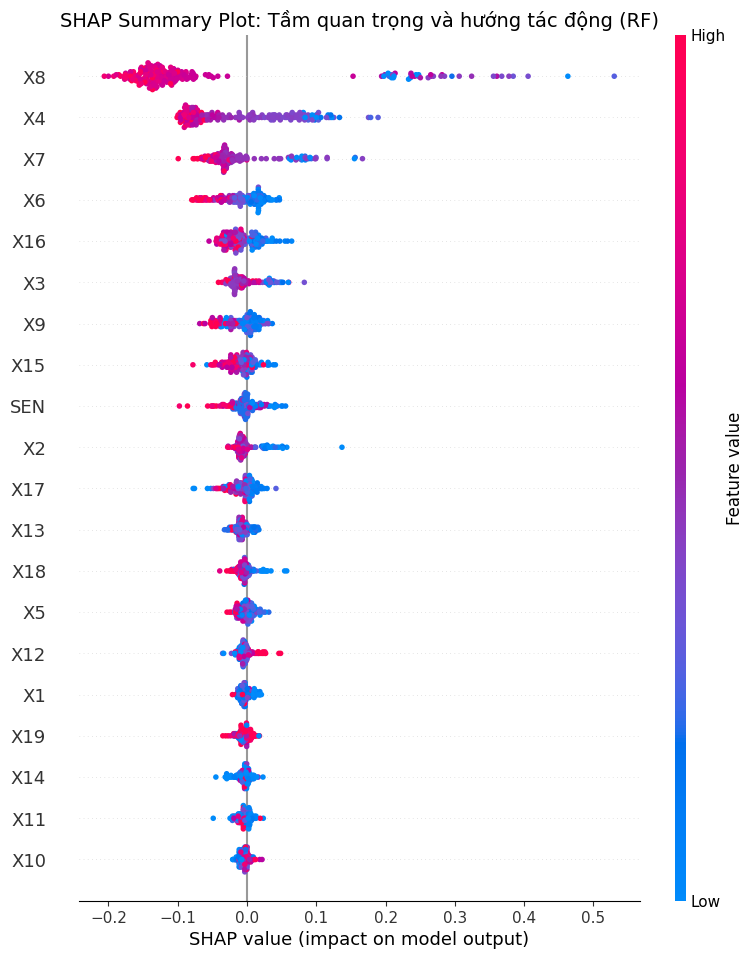


--- Đã tìm thấy mẫu có biến SEN tác động mạnh nhất: Index 105 ---


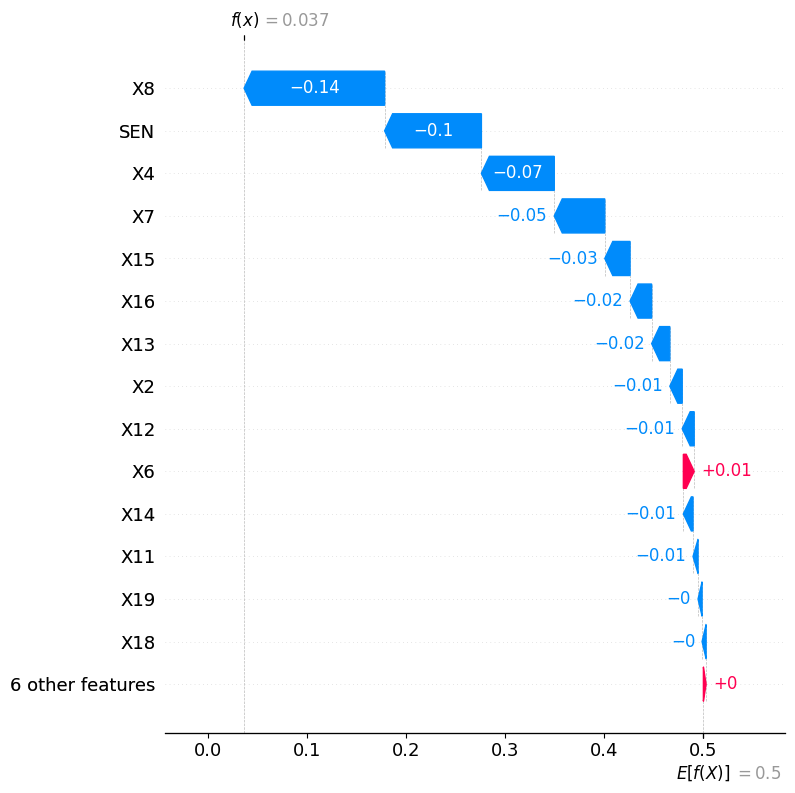

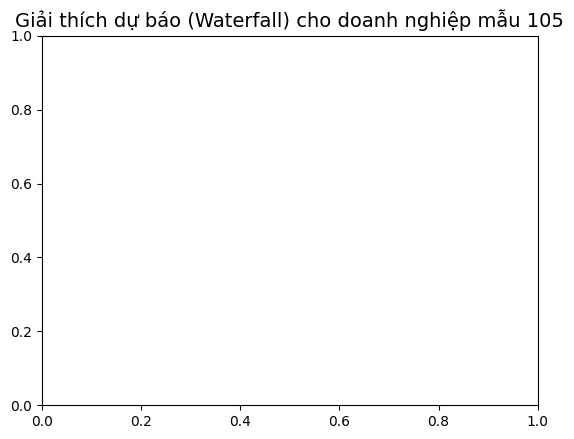

In [ ]:
import pandas as pd
import numpy as np
import wandb
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# 1. KẾT NỐI WANDB
WANDB_API_KEY = "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"
wandb.login(key=WANDB_API_KEY)
api = wandb.Api()

# 2. ĐỌC DỮ LIỆU
df_raw = pd.read_csv("/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv")
train_df = df_raw[df_raw['Year'] <= 2021].copy()
test_df  = df_raw[df_raw['Year'] == 2022].copy()

target = 'Next_year_binary_distress_label'
fin_vars = [f'X{i}' for i in range(1, 20)]
features_fin_sen = fin_vars + ['SEN']

# 3. LẤY THÔNG SỐ TỪ WANDB
run = api.run("22028316-uet-vnu/Distress_Prediction_KLTN/runs/nhxxygx7")
best_params = {k.replace('rf__', ''): v for k, v in run.config.items() if 'rf__' in k or k in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features', 'bootstrap']}

# 4. HUẤN LUYỆN LẠI PIPELINE
final_pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(**best_params, random_state=42))
])
final_pipe.fit(train_df[features_fin_sen], train_df[target])

# 5. CHUẨN BỊ CHO SHAP
X_test_scaled = final_pipe.named_steps['scaler'].transform(test_df[features_fin_sen])
rf_model = final_pipe.named_steps['rf']
explainer = shap.TreeExplainer(rf_model)

# Tính SHAP cho 200 mẫu
num_samples = 200
shap_values = explainer.shap_values(X_test_scaled[:num_samples])

# Trích xuất SHAP cho lớp Distress (thường là index 1)
if isinstance(shap_values, list):
    shap_values_distress = shap_values[1]
    expected_value = explainer.expected_value[1]
else:
    shap_values_distress = shap_values[:, :, 1]
    expected_value = explainer.expected_value[1]

# --- 6. VẼ BIỂU ĐỒ 1: SUMMARY PLOT ---
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_distress, X_test_scaled[:num_samples], feature_names=features_fin_sen, show=False)
plt.title("SHAP Summary Plot: Tầm quan trọng và hướng tác động (RF)", fontsize=14)
plt.show()

# --- 7. TỰ ĐỘNG TÌM MẪU CÓ SEN "XỊN" NHẤT ---
# Tìm vị trí cột SEN
sen_idx = features_fin_sen.index('SEN')
# Tìm index mẫu có giá trị SHAP của SEN lớn nhất (tuyệt đối)
best_sample_idx = np.argmax(np.abs(shap_values_distress[:, sen_idx]))

print(f"\n--- Đã tìm thấy mẫu có biến SEN tác động mạnh nhất: Index {best_sample_idx} ---")

# --- 8. VẼ BIỂU ĐỒ 2: WATERFALL PLOT CHO MẪU VỪA TÌM ĐƯỢC ---
plt.figure(figsize=(10, 8))
shap.plots._waterfall.waterfall_legacy(
    expected_value,
    shap_values_distress[best_sample_idx],
    feature_names=features_fin_sen,
    max_display=15 # Ép hiện ra 15 biến quan trọng nhất cho ca này
)
plt.title(f"Giải thích dự báo (Waterfall) cho doanh nghiệp mẫu {best_sample_idx}", fontsize=14)
plt.show()

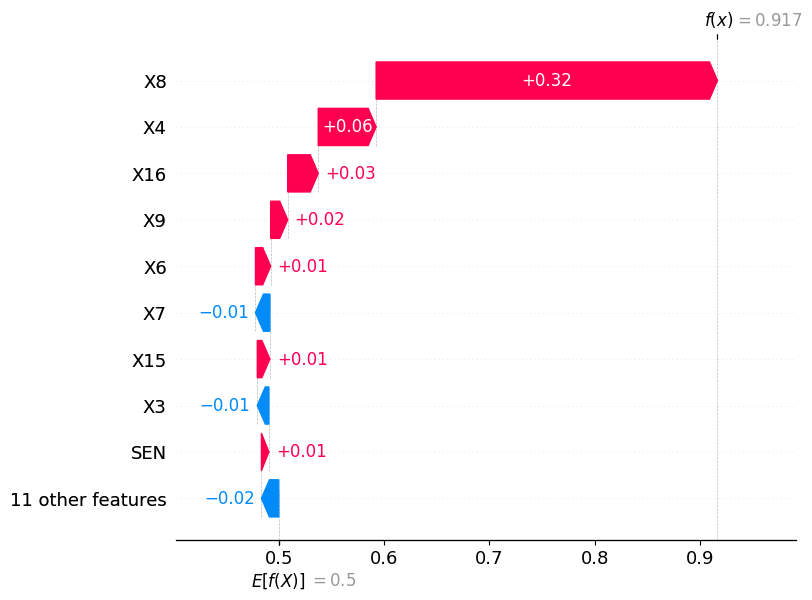

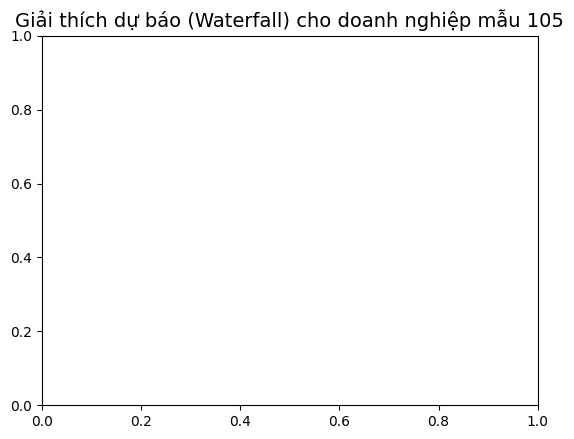

In [ ]:
# --- 8. VẼ BIỂU ĐỒ 2: WATERFALL PLOT CHO MẪU VỪA TÌM ĐƯỢC ---
plt.figure(figsize=(10, 8))
shap.plots._waterfall.waterfall_legacy(
    expected_value,
    shap_values_distress[11],
    feature_names=features_fin_sen,
    max_display=10 # Ép hiện ra 15 biến quan trọng nhất cho ca này
)
plt.title(f"Giải thích dự báo (Waterfall) cho doanh nghiệp mẫu {best_sample_idx}", fontsize=14)
plt.show()

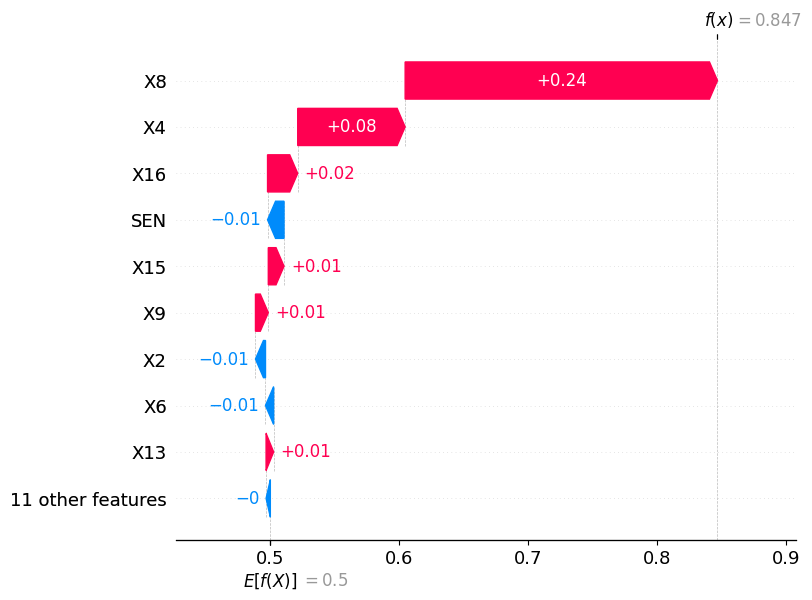

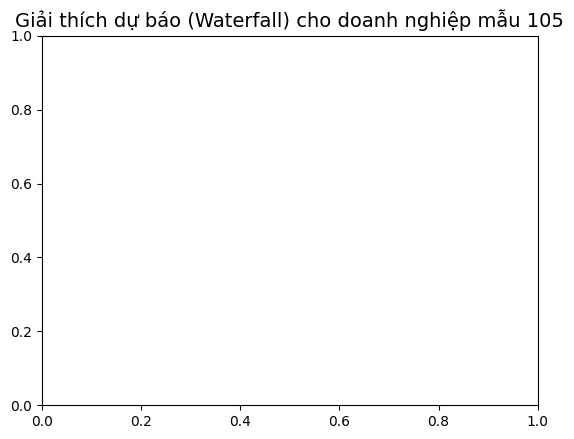

In [ ]:
# --- 8. VẼ BIỂU ĐỒ 2: WATERFALL PLOT CHO MẪU VỪA TÌM ĐƯỢC ---
plt.figure(figsize=(10, 8))
shap.plots._waterfall.waterfall_legacy(
    expected_value,
    shap_values_distress[15],
    feature_names=features_fin_sen,
    max_display=10 # Ép hiện ra 15 biến quan trọng nhất cho ca này
)
plt.title(f"Giải thích dự báo (Waterfall) cho doanh nghiệp mẫu {best_sample_idx}", fontsize=14)
plt.show()

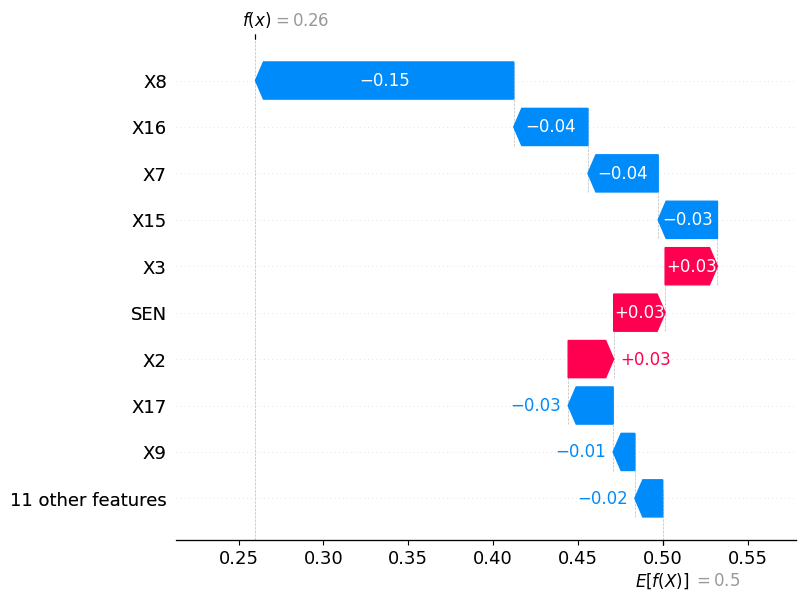

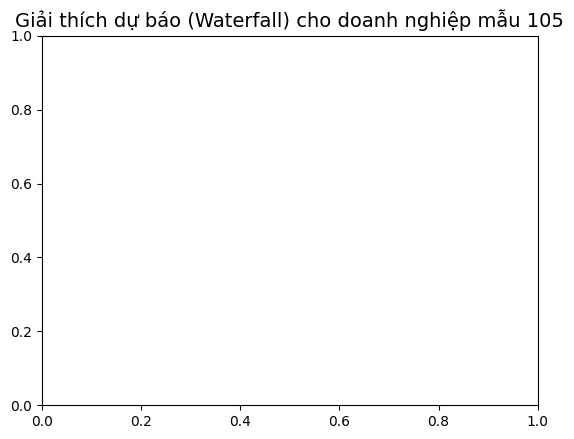

In [ ]:
# --- 8. VẼ BIỂU ĐỒ 2: WATERFALL PLOT CHO MẪU VỪA TÌM ĐƯỢC ---
plt.figure(figsize=(10, 8))
shap.plots._waterfall.waterfall_legacy(
    expected_value,
    shap_values_distress[23],
    feature_names=features_fin_sen,
    max_display=10 # Ép hiện ra 15 biến quan trọng nhất cho ca này
)
plt.title(f"Giải thích dự báo (Waterfall) cho doanh nghiệp mẫu {best_sample_idx}", fontsize=14)
plt.show()

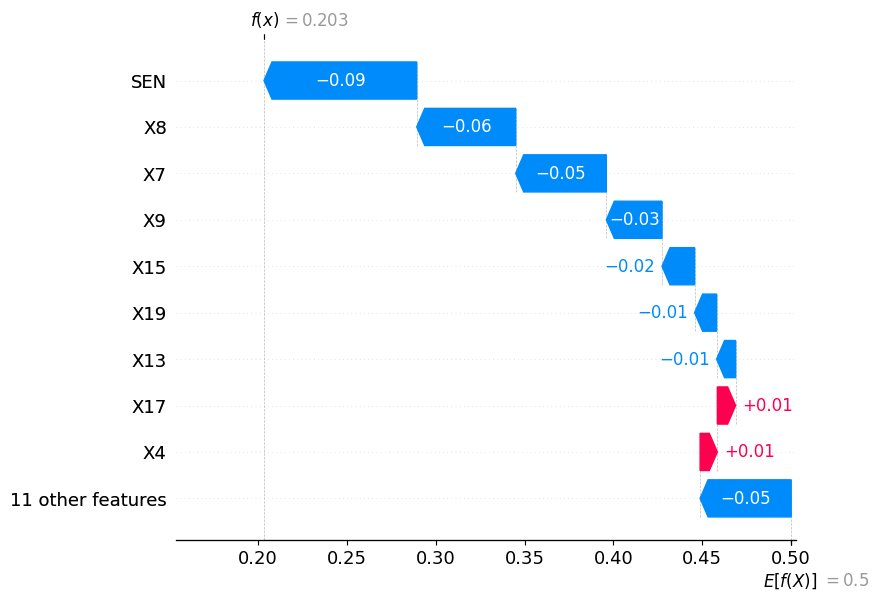

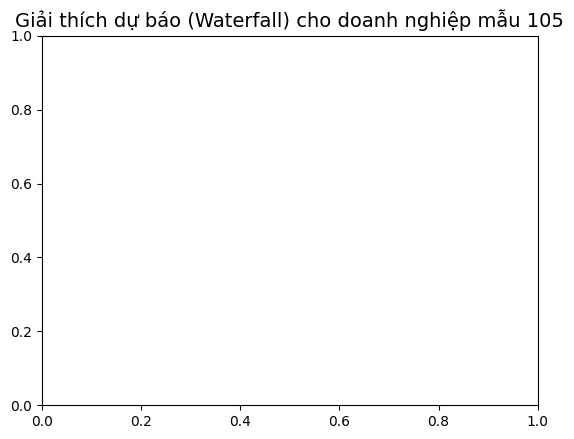

In [ ]:
# --- 8. VẼ BIỂU ĐỒ 2: WATERFALL PLOT CHO MẪU VỪA TÌM ĐƯỢC ---
plt.figure(figsize=(10, 8))
shap.plots._waterfall.waterfall_legacy(
    expected_value,
    shap_values_distress[27],
    feature_names=features_fin_sen,
    max_display=10 # Ép hiện ra 15 biến quan trọng nhất cho ca này
)
plt.title(f"Giải thích dự báo (Waterfall) cho doanh nghiệp mẫu {best_sample_idx}", fontsize=14)
plt.show()

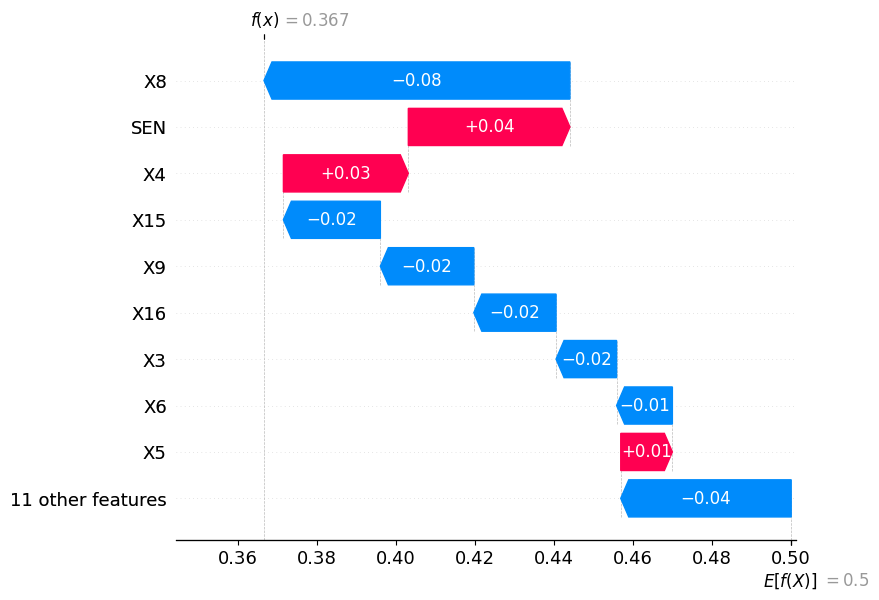

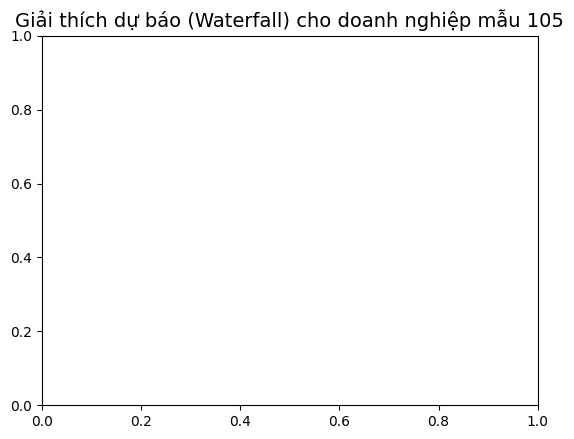

In [ ]:
# --- 8. VẼ BIỂU ĐỒ 2: WATERFALL PLOT CHO MẪU VỪA TÌM ĐƯỢC ---
plt.figure(figsize=(10, 8))
shap.plots._waterfall.waterfall_legacy(
    expected_value,
    shap_values_distress[28],
    feature_names=features_fin_sen,
    max_display=10 # Ép hiện ra 15 biến quan trọng nhất cho ca này
)
plt.title(f"Giải thích dự báo (Waterfall) cho doanh nghiệp mẫu {best_sample_idx}", fontsize=14)
plt.show()

In [ ]:
!pip install wandb
!pip install shap